In [8]:
import os
import numpy as np
import tifffile as tiff
import rasterio
import matplotlib.pyplot as plt

from PIL import Image

# Translated comment
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

In [9]:
def load_s2_swir_band(path, band_index=11):
    """
 Sentinel-2 : shape = (12, H, W)
 B12: index=11 (0-based)
    """
    arr = tiff.imread(path).astype(np.float32)
    if arr.ndim != 3 or arr.shape[0] != 12:
        raise ValueError(f"S2 shape error: {arr.shape}")
    return arr[band_index]  # (H, W)


def load_l8_swir_band(path, band_index=6):
    """
 Landsat 8/9 : shape = (8, H, W)
 B7: index=6 (0-based)
    """
    arr = tiff.imread(path).astype(np.float32)
    if arr.ndim != 3 or arr.shape[0] != 8:
        raise ValueError(f"L8/L9 shape error: {arr.shape}")
    return arr[band_index]  # (H, W)


def load_and_resize_mask(plume_id, target_shape, base_mask_dir="../carbon_mapper_data_masks"):
    """
 load plume mask, resize (H, W)
 path: ../carbon_mapper_data_masks/<plume_id>/plume.tif
    """
    mask_path = os.path.join(base_mask_dir, plume_id, "plume.tif")
    if not os.path.exists(mask_path):
        print(f"[warn] mask not found: {mask_path}")
        return None
    
    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    mask = (mask > 0).astype(np.uint8)

    H, W = target_shape
    img = Image.fromarray(mask)
    img = img.resize((W, H), resample=Image.NEAREST)
    return np.array(img)


In [10]:
def plume_contrast_z(band_img, mask):
    """
 band_img: (H, W) SWIR     mask: (H, W), 1=plume, 0=background

 Z-score :
        (mean_inside - mean_outside) / std_outside
    """
    if band_img.shape != mask.shape:
        raise ValueError(f"Shape mismatch: band {band_img.shape}, mask {mask.shape}")
    
    inside = band_img[mask == 1]
    outside = band_img[mask == 0]
    
    if inside.size == 0 or outside.size == 0:
        return np.nan
    
    mu_in = inside.mean()
    mu_out = outside.mean()
    std_out = outside.std()
    if std_out < 1e-6:
        return np.nan
    
    return float((mu_in - mu_out) / std_out)


In [11]:
# Translated comment
# Translated comment
def plume_contrast(mbmp, mask):
    """
    mbmp: (H, W) float32
    mask: (H, W) uint8, 1 = plume, 0 = background
 scalar, plume "".
    """
    if mbmp.shape != mask.shape:
        raise ValueError(f"Shape mismatch: mbmp {mbmp.shape}, mask {mask.shape}")
    
    inside = mbmp[mask == 1]
    outside = mbmp[mask == 0]
    
    if inside.size == 0 or outside.size == 0:
        return np.nan
    
    return float(inside.mean() - outside.mean())


In [12]:
SAMPLES = [
    dict(
        plume_id="av320250724t160634-A",
        s2_path="../carbonmapper_data_s2_l2a/av320250724t160634-A/s2_20250724T160829Z.tif",
        l8_path="../carbonmapper_data_l89_l2sp/av320250724t160634-A/l8_LC09_L2SP_018033_20250724_20250727_02_T1.tif",
    ),
    dict(
        plume_id="av320250724t160634-C",
        s2_path="../carbonmapper_data_s2_l2a/av320250724t160634-C/s2_20250724T160829Z.tif",
        l8_path="../carbonmapper_data_l89_l2sp/av320250724t160634-C/l8_LC09_L2SP_018032_20250724_20250727_02_T1.tif",
    ),
    dict(
        plume_id="av320250917t184127-A",
        s2_path="../carbonmapper_data_s2_l2a/av320250917t184127-A/s2_20250917T183919Z.tif",
        l8_path="../carbonmapper_data_l89_l2sp/av320250917t184127-A/l8_LC08_L2SP_043034_20250917_20250929_02_T1.tif",
    ),
    dict(
        plume_id="ang20220824t183643-A",
        s2_path="../carbonmapper_data_s2_l2a/ang20220824t183643-A/s2_20220824T183919Z.tif",
        l8_path="../carbonmapper_data_l89_l2sp/ang20220824t183643-A/l8_LC08_L2SP_043023_20220824_20220924_02_T1.tif",
    ),
    dict(
        plume_id="ang20220325t175529-A",
        s2_path="../carbonmapper_data_s2_l2a/ang20220325t175529-A/s2_20220325T175909Z.tif",
        l8_path="../carbonmapper_data_l89_l2sp/ang20220325t175529-A/l8_LC08_L2SP_035035_20220325_20220330_02_T1.tif",
    ),
]


In [13]:
s2_contrasts = []
l8_contrasts = []
plume_ids = []

for sample in SAMPLES:
    plume_id = sample["plume_id"]
    print(f"Processing plume {plume_id} ...")
    
    # Translated comment
    s2_band = load_s2_swir_band(sample["s2_path"], band_index=11)  # B12
    l8_band = load_l8_swir_band(sample["l8_path"], band_index=6)   # B7
    
    # 2) load mask
    mask = load_and_resize_mask(plume_id, s2_band.shape)
    if mask is None:
        print(f"    [warn] skip {plume_id} due to missing mask")
        continue
    
    # Translated comment
    c_s2 = plume_contrast_z(s2_band, mask)
    c_l8 = plume_contrast_z(l8_band, mask)
    
    print(f"    S2 Z-contrast = {c_s2:.3f}, L8 Z-contrast = {c_l8:.3f}")
    
    s2_contrasts.append(c_s2)
    l8_contrasts.append(c_l8)
    plume_ids.append(plume_id)

s2_contrasts = np.array(s2_contrasts)
l8_contrasts = np.array(l8_contrasts)


Processing plume av320250724t160634-A ...
    S2 Z-contrast = 0.148, L8 Z-contrast = -0.001
Processing plume av320250724t160634-C ...
    S2 Z-contrast = 0.001, L8 Z-contrast = -0.090
Processing plume av320250917t184127-A ...
    S2 Z-contrast = -0.262, L8 Z-contrast = -0.094
Processing plume ang20220824t183643-A ...
    S2 Z-contrast = 0.242, L8 Z-contrast = 0.358
Processing plume ang20220325t175529-A ...
    S2 Z-contrast = 0.589, L8 Z-contrast = 0.604


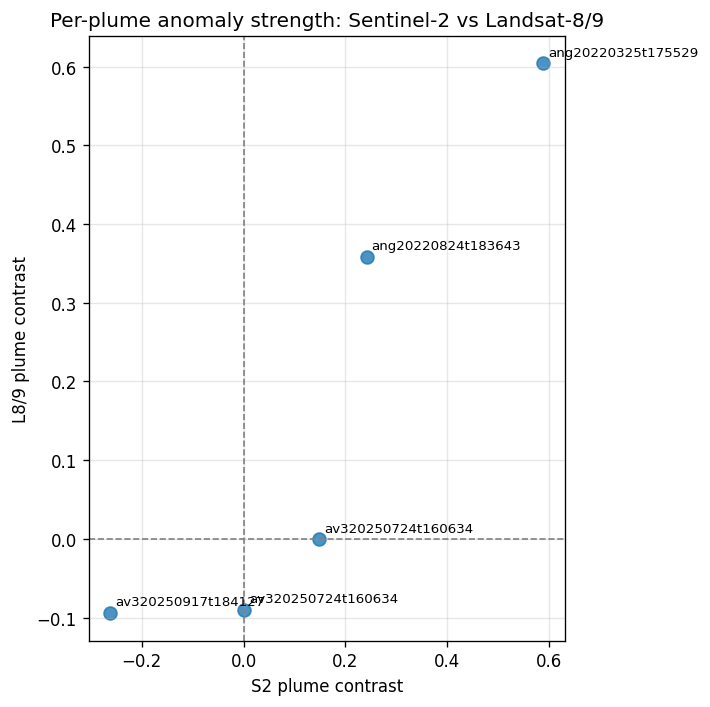

In [14]:
# Translated comment
plt.figure(figsize=(6,6))

# Translated comment
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)

plt.scatter(s2_contrasts, l8_contrasts, s=60, alpha=0.8)

for x, y, pid in zip(s2_contrasts, l8_contrasts, plume_ids):
    short = pid.split("-")[0]
    plt.text(x + 0.01, y + 0.01, short, fontsize=8)

plt.xlabel("S2 plume contrast")
plt.ylabel("L8/9 plume contrast")
plt.title("Per-plume anomaly strength: Sentinel-2 vs Landsat-8/9")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [17]:
def plot_swir_hist_for_plume(sample, nbins=40):
    plume_id = sample["plume_id"]
    print(f"Plotting SWIR histogram for plume {plume_id} ...")
    
    # Translated comment
    s2_band = load_s2_swir_band(sample["s2_path"], band_index=11)  # B12
    l8_band = load_l8_swir_band(sample["l8_path"], band_index=6)   # B7
    
    # Translated comment
    mask = load_and_resize_mask(plume_id, s2_band.shape)
    if mask is None:
        print("  [warn] mask missing, skip.")
        return
    
    # Translated comment
    s2_plume_vals = s2_band[mask == 1]
    l8_plume_vals = l8_band[mask == 1]
    
    # Translated comment
    all_vals = np.concatenate([s2_plume_vals, l8_plume_vals])
    vmin = np.percentile(all_vals, 1)
    vmax = np.percentile(all_vals, 99)
    bins = np.linspace(vmin, vmax, nbins)
    
    fig, ax = plt.subplots(figsize=(6,4))
    
    ax.hist(s2_plume_vals, bins=bins, density=True, alpha=0.5,
            label="S2 plume (B12)", edgecolor="none")
    ax.hist(l8_plume_vals, bins=bins, density=True, alpha=0.5,
            label="L8/9 plume (B7)", edgecolor="none")
    
    ax.set_xlabel("SWIR DN / reflectance (scaled)")
    ax.set_ylabel("Density")
    ax.set_title(f"SWIR plume histogram\n{plume_id}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


Plotting SWIR histogram for plume av320250724t160634-A ...


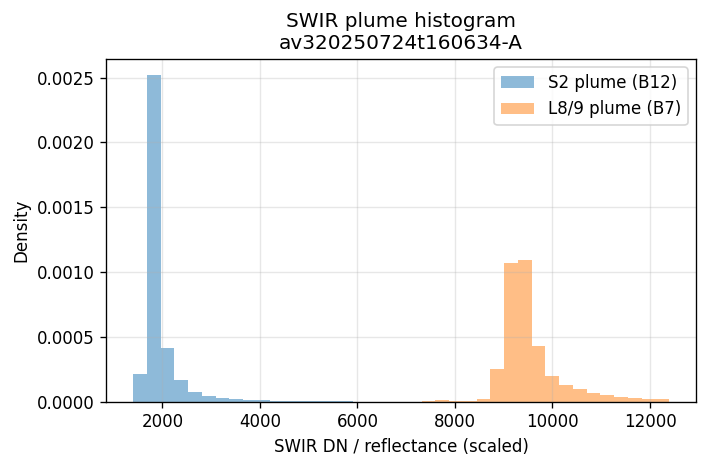

Plotting SWIR histogram for plume av320250724t160634-C ...


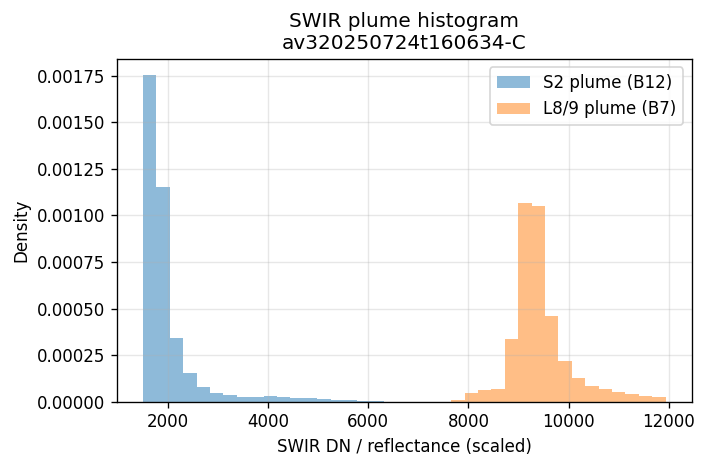

Plotting SWIR histogram for plume av320250917t184127-A ...


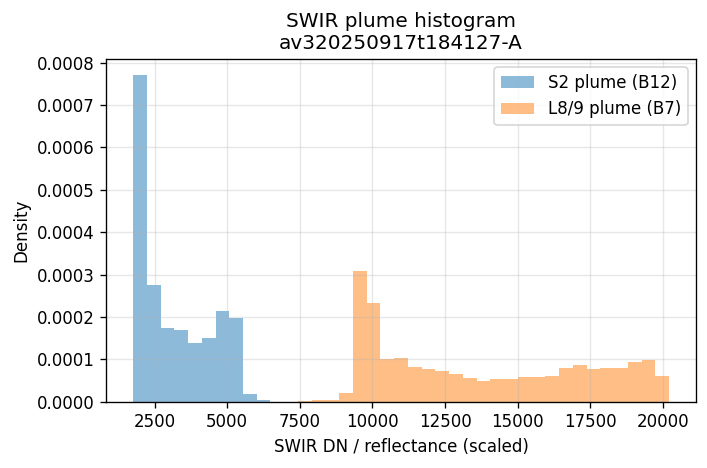

Plotting SWIR histogram for plume ang20220824t183643-A ...


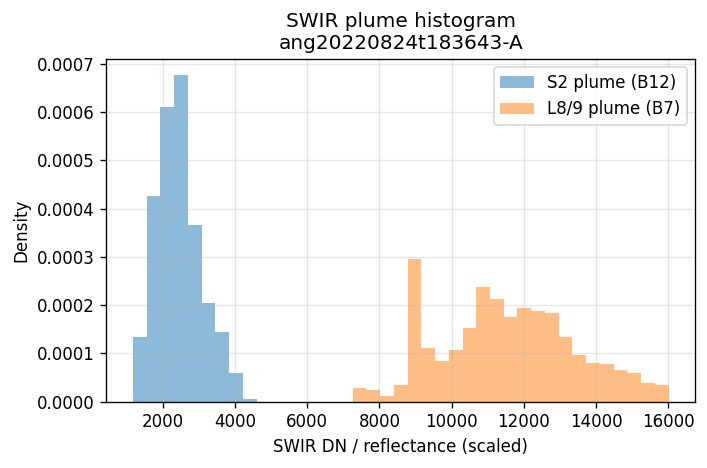

Plotting SWIR histogram for plume ang20220325t175529-A ...


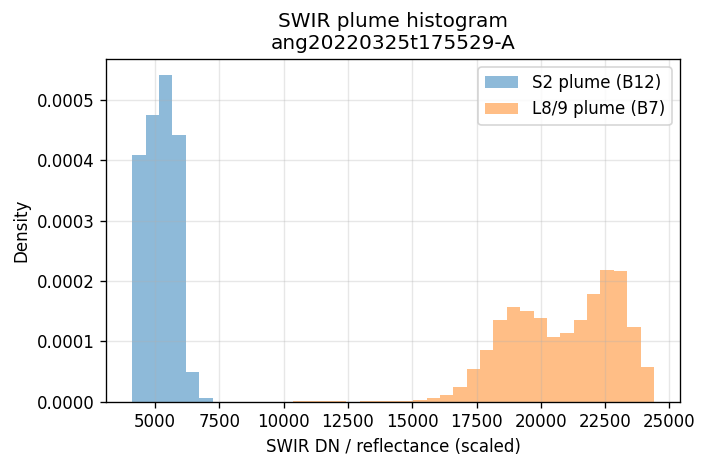

In [18]:
for sample in SAMPLES:
    plot_swir_hist_for_plume(sample, nbins=40)


In [29]:
def zscore_anomaly_map(band_img, mask=None):
    """
 band_img: (H, W) SWIR  mask: optional (H, W) plume mask., mask==0 ;  figure.
 :
 z_norm: (H, W) [0,1] Z-score map(figure)
 z_raw: (H, W) Z-score
    """
    if mask is not None:
        bg_vals = band_img[mask == 0]
    else:
        bg_vals = band_img.reshape(-1)
    
    mu = bg_vals.mean()
    std = bg_vals.std() + 1e-6
    
    z = (band_img - mu) / std  # Translated comment

    # Translated comment
    z_clipped = np.clip(z, -3.0, 3.0)
    z_norm = (z_clipped + 3.0) / 6.0  # [-3,3] -> [0,1]
    return z_norm.astype(np.float32), z



In [34]:
def plot_zscore_maps_for_plume(sample):
    plume_id = sample["plume_id"]
    print(f"Plotting Z-score maps for plume {plume_id} ...")
    
    # 1) SWIR band
    s2_band = load_s2_swir_band(sample["s2_path"], band_index=11)  # B12
    l8_band = load_l8_swir_band(sample["l8_path"], band_index=6)   # B7
    
    # 2) mask
    mask = load_and_resize_mask(plume_id, s2_band.shape)
    if mask is None:
        print("  [warn] mask missing, skip.")
        return
    
    # 3) Z-score anomaly map
    s2_z_norm, s2_z_raw = zscore_anomaly_map(s2_band, mask=None)  # Translated comment
    l8_z_norm, l8_z_raw = zscore_anomaly_map(l8_band, mask=None)
    
    # Translated comment
    fig, axes = plt.subplots(1, 2, figsize=(9,4))
    
    # S2
    ax = axes[0]
    im = ax.imshow(s2_z_norm, cmap="coolwarm", vmin=0, vmax=1)
    ax.imshow(np.ma.masked_where(mask == 0, mask),
              cmap="jet", alpha=0.35)
    ax.set_title(f"{plume_id}\nS2 SWIR (B12) Z-score + plume mask")
    ax.axis("off")
    
    # L8
    ax = axes[1]
    ax.imshow(l8_z_norm, cmap="coolwarm", vmin=0, vmax=1)
    ax.imshow(np.ma.masked_where(mask == 0, mask),
              cmap="jet", alpha=0.35)
    ax.set_title(f"{plume_id}\nL8/9 SWIR (B7) Z-score + plume mask")
    ax.axis("off")
    
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7, label="Z-score (normalized)")
    plt.tight_layout()
    plt.show()


Plotting Z-score maps for plume av320250724t160634-A ...


/tmp/ipykernel_116547/647660616.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


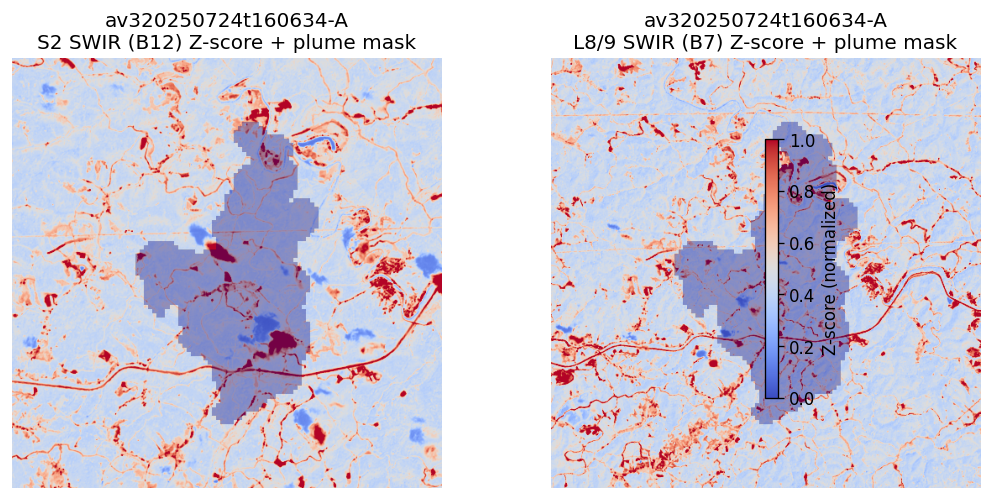

Plotting Z-score maps for plume av320250724t160634-C ...


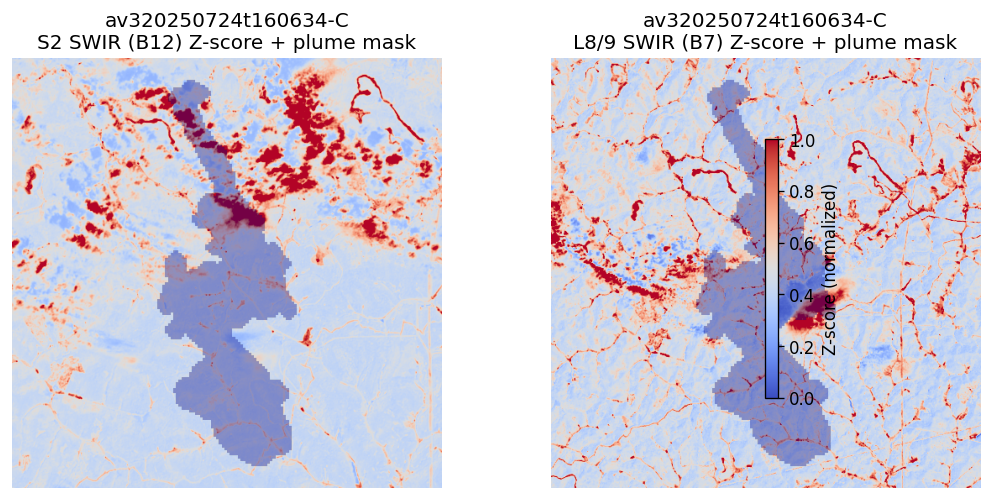

Plotting Z-score maps for plume av320250917t184127-A ...


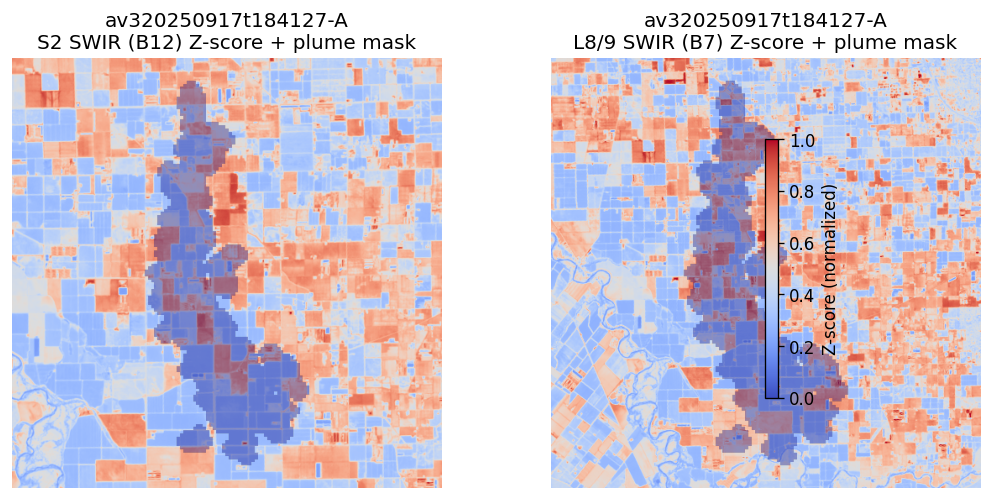

Plotting Z-score maps for plume ang20220824t183643-A ...


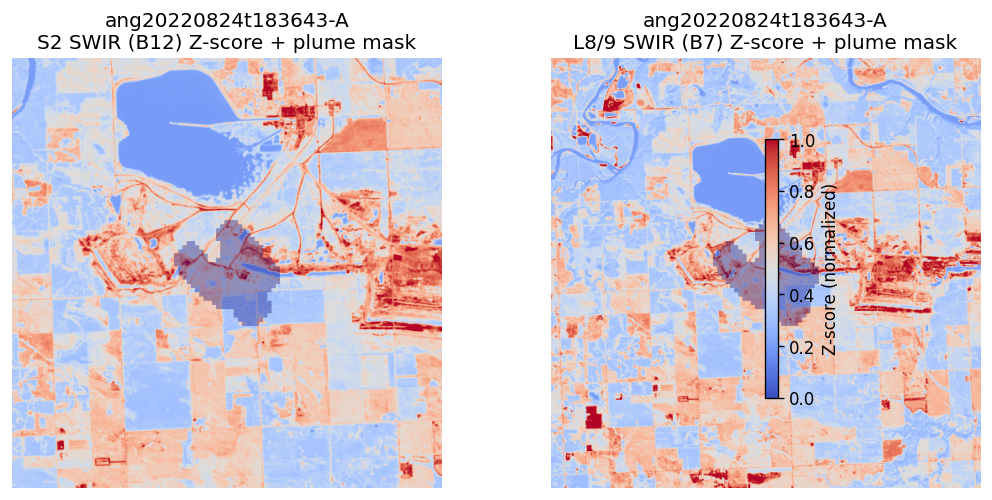

Plotting Z-score maps for plume ang20220325t175529-A ...


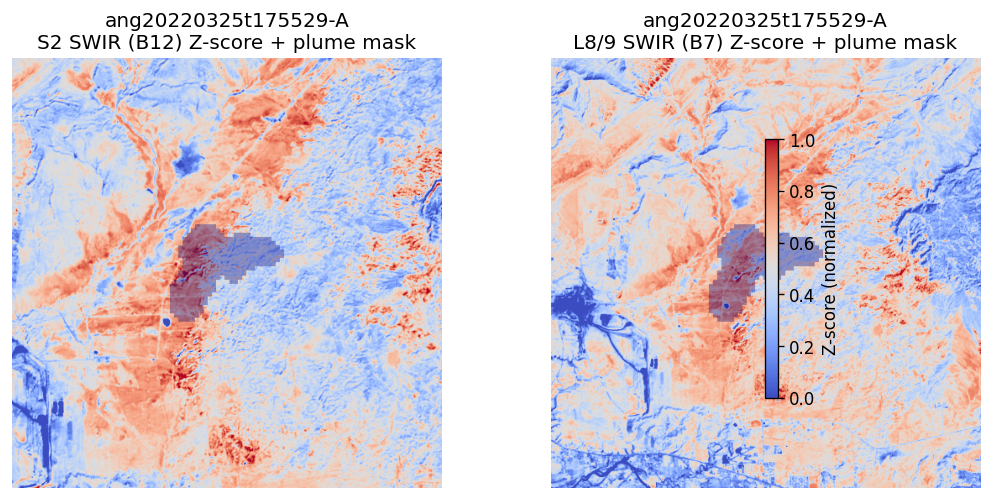

In [35]:
for sample in SAMPLES:
    plot_zscore_maps_for_plume(sample)


Processing av320250724t160634-A ...
Processing av320250724t160634-C ...
Processing av320250917t184127-A ...
Processing ang20220824t183643-A ...
Processing ang20220325t175529-A ...
S2 d-shape: (5, 12)
L8 d-shape: (5, 8)
=== Sentinel-2 band ranking (by |effect size|) ===
 B01: mean |d| = 0.413
 B03: mean |d| = 0.394
 B02: mean |d| = 0.372
 B04: mean |d| = 0.365
 B05: mean |d| = 0.363
 B12: mean |d| = 0.282
 B07: mean |d| = 0.233
 B8A: mean |d| = 0.223
 B11: mean |d| = 0.202
 B06: mean |d| = 0.173
  X9: mean |d| = 0.000
  X8: mean |d| = 0.000

=== Landsat 8/9 band ranking (by |effect size|) ===
  B1: mean |d| = 0.278
  B2: mean |d| = 0.238
  B3: mean |d| = 0.210
  B4: mean |d| = 0.172
  B7: mean |d| = 0.165
 B10: mean |d| = 0.157
  B6: mean |d| = 0.145
  B5: mean |d| = 0.140


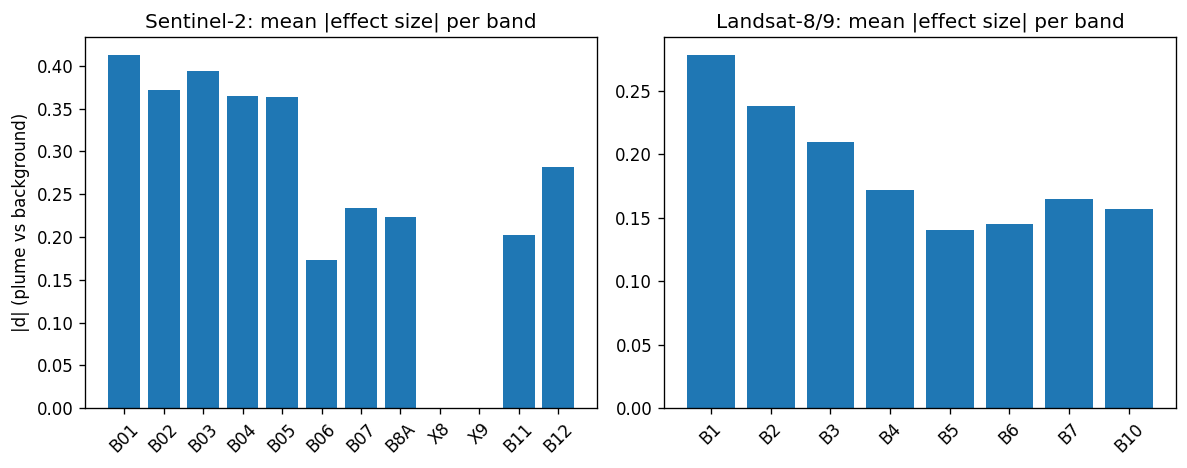

In [ ]:
import os
import numpy as np
import tifffile as tiff
import rasterio
from PIL import Image
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

# ---------- load stacks ----------

def load_s2_stack(path):
    arr = tiff.imread(path).astype(np.float32)  # (12,H,W)
    if arr.ndim != 3 or arr.shape[0] != 12:
        raise ValueError(f"S2 shape error: {arr.shape}")
    return arr

def load_l8_stack(path):
    arr = tiff.imread(path).astype(np.float32)  # (8,H,W)
    if arr.ndim != 3 or arr.shape[0] != 8:
        raise ValueError(f"L8 stack shape error: {arr.shape}")
    return arr

def load_mask_and_con(plume_id, target_shape,
                      base_dir="../carbon_mapper_data_masks"):
    """
 load plume.tif con.tif, resize target_shape=(H,W)
    """
    plume_path = os.path.join(base_dir, plume_id, "plume.tif")
    con_path   = os.path.join(base_dir, plume_id, "con.tif")
    
    if not os.path.exists(plume_path):
        print(f"[warn] plume mask missing: {plume_path}")
        return None, None
    
    with rasterio.open(plume_path) as src:
        plume = src.read(1)
    plume = (plume > 0).astype(np.uint8)
    
    H, W = target_shape
    # resize plume
    plume_img = Image.fromarray(plume)
    plume_resized = plume_img.resize((W, H), resample=Image.NEAREST)
    plume_resized = np.array(plume_resized).astype(np.uint8)
    
    con_resized = None
    if os.path.exists(con_path):
        with rasterio.open(con_path) as src:
            con = src.read(1).astype(np.float32)
        con_img = Image.fromarray(con)
        con_resized = con_img.resize((W, H), resample=Image.BILINEAR)
        con_resized = np.array(con_resized).astype(np.float32)
    else:
        print(f"[warn] con.tif missing: {con_path}")
    
    return plume_resized, con_resized

def band_effect_scores(stack, plume_mask, con_map=None,
                       use_core=True, core_percentile=70):
    """
 stack (C,H,W), band plume vs effect size.

 :
 d_scores: (C,) band effect size d
 fisher_scores: (C,) band Fisher score
    """
    C, H, W = stack.shape
    plume = plume_mask == 1
    
    if con_map is not None and use_core:
        # Translated comment
        vals = con_map[plume]
        if vals.size > 0:
            thr = np.percentile(vals, core_percentile)
            plume_core = plume & (con_map >= thr)
        else:
            plume_core = plume
    else:
        plume_core = plume
    
    inside = plume_core
    outside = plume_mask == 0
    
    d_list = []
    f_list = []
    
    for b in range(C):
        img = stack[b]
        in_vals  = img[inside]
        out_vals = img[outside]
        
        if in_vals.size < 5 or out_vals.size < 5:
            d_list.append(np.nan)
            f_list.append(np.nan)
            continue
        
        mu_in, mu_out = in_vals.mean(), out_vals.mean()
        std_in = in_vals.std() + 1e-6
        std_out = out_vals.std() + 1e-6
        
        # Translated comment
        pooled = 0.5 * (std_in + std_out)
        d = (mu_in - mu_out) / pooled
        
        # Fisher score
        f = (mu_in - mu_out)**2 / (std_in**2 + std_out**2)
        
        d_list.append(d)
        f_list.append(f)
    
    return np.array(d_list), np.array(f_list)

# S2: 12 bands, L8: 8 bands
all_s2_d = []
all_l8_d = []

for sample in SAMPLES:
    plume_id = sample["plume_id"]
    print(f"Processing {plume_id} ...")
    
    # load stacks
    s2_stack = load_s2_stack(sample["s2_path"])
    l8_stack = load_l8_stack(sample["l8_path"])
    
    # mask & con
    H, W = s2_stack.shape[1:]
    plume_mask, con_map = load_mask_and_con(plume_id, (H, W))
    if plume_mask is None:
        print("  [warn] no mask, skip.")
        continue
    
    # S2 scores
    s2_d, s2_f = band_effect_scores(s2_stack, plume_mask, con_map,
                                    use_core=True, core_percentile=70)
    all_s2_d.append(s2_d)
    
    # L8 scores
    l8_d, l8_f = band_effect_scores(l8_stack, plume_mask, con_map,
                                    use_core=True, core_percentile=70)
    all_l8_d.append(l8_d)

all_s2_d = np.stack(all_s2_d, axis=0)   # (num_plumes, 12)
all_l8_d = np.stack(all_l8_d, axis=0)   # (num_plumes, 8)

print("S2 d-shape:", all_s2_d.shape)
print("L8 d-shape:", all_l8_d.shape)

s2_band_names = [
    "B01","B02","B03","B04","B05","B06","B07","B8A","X8","X9","B11","B12"
]
# Translated comment

l8_band_names = [
    "B1","B2","B3","B4","B5","B6","B7","B10"
]

mean_abs_s2 = np.nanmean(np.abs(all_s2_d), axis=0)
mean_abs_l8 = np.nanmean(np.abs(all_l8_d), axis=0)

# Translated comment
s2_rank_idx = np.argsort(-mean_abs_s2)  # Translated comment
l8_rank_idx = np.argsort(-mean_abs_l8)

print("=== Sentinel-2 band ranking (by |effect size|) ===")
for i in s2_rank_idx:
    print(f"{s2_band_names[i]:>4s}: mean |d| = {mean_abs_s2[i]:.3f}")

print("\n=== Landsat 8/9 band ranking (by |effect size|) ===")
for i in l8_rank_idx:
    print(f"{l8_band_names[i]:>4s}: mean |d| = {mean_abs_l8[i]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10,4))

# S2
ax = axes[0]
ax.bar(np.arange(len(s2_band_names)), mean_abs_s2)
ax.set_xticks(np.arange(len(s2_band_names)))
ax.set_xticklabels(s2_band_names, rotation=45)
ax.set_title("Sentinel-2: mean |effect size| per band")
ax.set_ylabel("|d| (plume vs background)")

# L8
ax = axes[1]
ax.bar(np.arange(len(l8_band_names)), mean_abs_l8)
ax.set_xticks(np.arange(len(l8_band_names)))
ax.set_xticklabels(l8_band_names, rotation=45)
ax.set_title("Landsat-8/9: mean |effect size| per band")

plt.tight_layout()
plt.show()



In [42]:
import numpy as np

def band_con_corr_con_only(stack, con_map,
                           con_low_q=10, con_high_q=90,
                           con_min_positive=0.0):
    """
 plume.tif, con.tif band Pearson .
    stack: (C, H, W)
    con_map: (H, W)
 : r_vals, shape=(C,)
    """
    C, H, W = stack.shape
    if con_map is None:
        return np.full(C, np.nan, dtype=np.float32)
    
    con_flat = con_map.astype(np.float32).reshape(-1)

    # Translated comment
    valid0 = np.isfinite(con_flat) & (con_flat > con_min_positive)
    if valid0.sum() < 50:
        # Translated comment
        return np.full(C, np.nan, dtype=np.float32)

    con_valid = con_flat[valid0]

    # Translated comment
    lo = np.percentile(con_valid, con_low_q)
    hi = np.percentile(con_valid, con_high_q)
    valid = valid0 & (con_flat >= lo) & (con_flat <= hi)

    if valid.sum() < 50:
        return np.full(C, np.nan, dtype=np.float32)

    con_sel = con_flat[valid]  # (N,)

    r_list = []
    for b in range(C):
        band_flat = stack[b].astype(np.float32).reshape(-1)
        band_sel = band_flat[valid]
        if band_sel.size < 50:
            r_list.append(np.nan)
            continue

        x = band_sel - band_sel.mean()
        y = con_sel  - con_sel.mean()
        denom = np.sqrt((x**2).sum()) * np.sqrt((y**2).sum()) + 1e-8
        r = float((x * y).sum() / denom)
        r_list.append(r)

    return np.array(r_list, dtype=np.float32)


all_s2_r = []
all_l8_r = []

for sample in SAMPLES:
    plume_id = sample["plume_id"]
    print(f"Processing {plume_id} ...")

    s2_stack = load_s2_stack(sample["s2_path"])
    l8_stack = load_l8_stack(sample["l8_path"])
    H, W = s2_stack.shape[1:]
    plume_mask, con_map = load_mask_and_con(plume_id, (H, W))
    if plume_mask is None or con_map is None:
        print("  [warn] missing mask or con, skip.")
        continue
    

    s2_r = band_con_corr_con_only(s2_stack, con_map)
    l8_r = band_con_corr_con_only(l8_stack, con_map)

    all_s2_r.append(s2_r)
    all_l8_r.append(l8_r)

all_s2_r = np.stack(all_s2_r, axis=0)  # (n_plumes, 12)
all_l8_r = np.stack(all_l8_r, axis=0)  # (n_plumes, 8)

mean_abs_s2_r = np.nanmean(np.abs(all_s2_r), axis=0)
mean_abs_l8_r = np.nanmean(np.abs(all_l8_r), axis=0)
s2_band_names = ["B01","B02","B03","B04","B05","B06","B07","B8A","X8","X9","B11","B12"]
l8_band_names = ["B1","B2","B3","B4","B5","B6","B7","B10"]

s2_rank_idx = np.argsort(-mean_abs_s2_r)
l8_rank_idx = np.argsort(-mean_abs_l8_r)

print("=== S2 band ranking by |corr(con)| ===")
for i in s2_rank_idx:
    print(f"{s2_band_names[i]:>4s}: mean |r| = {mean_abs_s2_r[i]:.3f}")

print("\n=== L8 band ranking by |corr(con)| ===")
for i in l8_rank_idx:
    print(f"{l8_band_names[i]:>4s}: mean |r| = {mean_abs_l8_r[i]:.3f}")

Processing av320250724t160634-A ...
Processing av320250724t160634-C ...
Processing av320250917t184127-A ...
Processing ang20220824t183643-A ...
Processing ang20220325t175529-A ...
=== S2 band ranking by |corr(con)| ===
 B01: mean |r| = 0.085
 B02: mean |r| = 0.075
 B03: mean |r| = 0.070
 B04: mean |r| = 0.069
 B12: mean |r| = 0.063
 B05: mean |r| = 0.051
 B8A: mean |r| = 0.046
 B06: mean |r| = 0.039
 B07: mean |r| = 0.038
 B11: mean |r| = 0.037
  X9: mean |r| = 0.000
  X8: mean |r| = 0.000

=== L8 band ranking by |corr(con)| ===
  B5: mean |r| = 0.079
 B10: mean |r| = 0.051
  B2: mean |r| = 0.038
  B4: mean |r| = 0.035
  B1: mean |r| = 0.033
  B7: mean |r| = 0.032
  B3: mean |r| = 0.029
  B6: mean |r| = 0.025


Processing av320250724t160634-A ...
  R² S2-only  = 0.008
  R² L8-only  = 0.014
  R² S2+L8    = 0.024
Processing av320250724t160634-C ...
  R² S2-only  = 0.043
  R² L8-only  = 0.019
  R² S2+L8    = 0.059
Processing av320250917t184127-A ...
  R² S2-only  = 0.079
  R² L8-only  = 0.033
  R² S2+L8    = 0.110
Processing ang20220824t183643-A ...
  R² S2-only  = 0.045
  R² L8-only  = 0.029
  R² S2+L8    = 0.076
Processing ang20220325t175529-A ...
  R² S2-only  = 0.004
  R² L8-only  = 0.006
  R² S2+L8    = 0.010

==== Mean R² over all plumes ====
S2-only : 0.036 ± 0.028
L8-only : 0.020 ± 0.009
S2+L8   : 0.056 ± 0.036


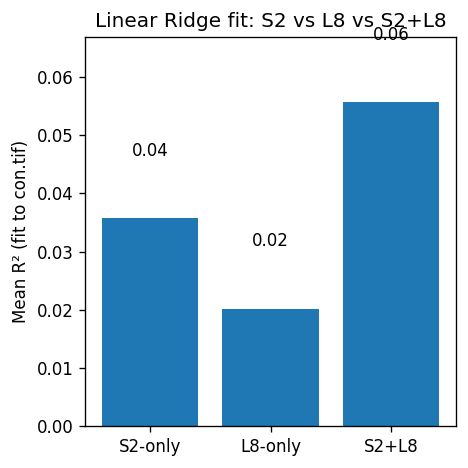

In [55]:
# Translated comment
# Translated comment

import os
import numpy as np
import tifffile as tiff
import rasterio
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

# ------------------------------------------------
# Translated comment
# ------------------------------------------------

SAMPLES = [
    dict(
        plume_id="av320250724t160634-A",
        s2_path="../carbonmapper_data_s2_l2a/av320250724t160634-A/s2_20250724T160829Z.tif",
        l8_path="../carbonmapper_data_l89_l2sp/av320250724t160634-A/l8_LC09_L2SP_018033_20250724_20250727_02_T1.tif",
    ),
    dict(
        plume_id="av320250724t160634-C",
        s2_path="../carbonmapper_data_s2_l2a/av320250724t160634-C/s2_20250724T160829Z.tif",
        l8_path="../carbonmapper_data_l89_l2sp/av320250724t160634-C/l8_LC09_L2SP_018032_20250724_20250727_02_T1.tif",
    ),
    dict(
        plume_id="av320250917t184127-A",
        s2_path="../carbonmapper_data_s2_l2a/av320250917t184127-A/s2_20250917T183919Z.tif",
        l8_path="../carbonmapper_data_l89_l2sp/av320250917t184127-A/l8_LC08_L2SP_043034_20250917_20250929_02_T1.tif",
    ),
    dict(
        plume_id="ang20220824t183643-A",
        s2_path="../carbonmapper_data_s2_l2a/ang20220824t183643-A/s2_20220824T183919Z.tif",
        l8_path="../carbonmapper_data_l89_l2sp/ang20220824t183643-A/l8_LC08_L2SP_043023_20220824_20220924_02_T1.tif",
    ),
    dict(
        plume_id="ang20220325t175529-A",
        s2_path="../carbonmapper_data_s2_l2a/ang20220325t175529-A/s2_20220325T175909Z.tif",
        l8_path="../carbonmapper_data_l89_l2sp/ang20220325t175529-A/l8_LC08_L2SP_035035_20220325_20220330_02_T1.tif",
    ),
]

# Translated comment
S2_USE_BANDS = [4, 5, 6, 7, 10, 11]
S2_BAND_NAMES = ["B05","B06","B07","B8A","B11","B12"]

# Translated comment
L8_USE_BANDS = [1, 2, 3, 4, 5, 6, 7]
L8_BAND_NAMES = ["B5","B6","B7", "B10"]

MASK_DIR = "../carbon_mapper_data_masks"


# ------------------------------------------------
# Translated comment
# ------------------------------------------------

def load_s2_stack(path):
    arr = tiff.imread(path).astype(np.float32)  # (12,H,W)
    if arr.ndim != 3:
        raise ValueError(f"S2 stack dim error: {arr.shape}")
    return arr

def load_l8_stack(path):
    arr = tiff.imread(path).astype(np.float32)  # (8,H,W)
    if arr.ndim != 3:
        raise ValueError(f"L8 stack dim error: {arr.shape}")
    return arr

def load_con(plume_id, target_shape, base_dir=MASK_DIR):
    con_path = os.path.join(base_dir, plume_id, "con.tif")
    if not os.path.exists(con_path):
        print(f"[warn] con.tif missing: {con_path}")
        return None
    with rasterio.open(con_path) as src:
        con = src.read(1).astype(np.float32)
    H, W = target_shape
    img = Image.fromarray(con)
    img = img.resize((W, H), resample=Image.BILINEAR)
    return np.array(img).astype(np.float32)


# ------------------------------------------------
# Translated comment
# ------------------------------------------------

def build_features_and_target(s2_stack, l8_stack, con_map,
                              con_min_positive=0.0,
                              con_low_q=10,
                              con_high_q=90):
    """
 :
      X_s2: (N, C_s2)
      X_l8: (N, C_l8)
      y:    (N,)
 con , [q_low, q_high] .
    """
    H, W = con_map.shape
    con_flat = con_map.reshape(-1)

    valid0 = np.isfinite(con_flat) & (con_flat > con_min_positive)
    if valid0.sum() < 100:
        return None, None, None

    vals = con_flat[valid0]
    lo = np.percentile(vals, con_low_q)
    hi = np.percentile(vals, con_high_q)
    valid = valid0 & (con_flat >= lo) & (con_flat <= hi)

    if valid.sum() < 100:
        return None, None, None

    y = con_flat[valid]  # (N,)

    # Translated comment
    s2_sub = s2_stack[S2_USE_BANDS, :, :]  # (C_s2, H, W)
    l8_sub = l8_stack[L8_USE_BANDS, :, :]  # (C_l8, H, W)

    X_s2 = s2_sub.reshape(len(S2_USE_BANDS), -1).T[valid]  # (N, C_s2)
    X_l8 = l8_sub.reshape(len(L8_USE_BANDS), -1).T[valid]  # (N, C_l8)

    # Translated comment
    def standardize(X):
        mean = X.mean(axis=0, keepdims=True)
        std = X.std(axis=0, keepdims=True) + 1e-6
        return (X - mean) / std

    X_s2 = standardize(X_s2)
    X_l8 = standardize(X_l8)

    return X_s2, X_l8, y


ridge = Ridge(alpha=1.0)

r2_s2_list = []
r2_l8_list = []
r2_both_list = []

for sample in SAMPLES:
    plume_id = sample["plume_id"]
    print(f"Processing {plume_id} ...")
    s2_stack = load_s2_stack(sample["s2_path"])
    l8_stack = load_l8_stack(sample["l8_path"])
    H, W = s2_stack.shape[1:]
    con_map = load_con(plume_id, (H, W))

    if con_map is None:
        print("  [warn] skip (no con)")
        continue

    X_s2, X_l8, y = build_features_and_target(s2_stack, l8_stack, con_map)
    if X_s2 is None:
        print("  [warn] skip (too few valid pixels).")
        continue

    # S2 only
    ridge_s2 = Ridge(alpha=1.0)
    ridge_s2.fit(X_s2, y)
    r2_s2 = ridge_s2.score(X_s2, y)

    # L8 only
    ridge_l8 = Ridge(alpha=1.0)
    ridge_l8.fit(X_l8, y)
    r2_l8 = ridge_l8.score(X_l8, y)

    # S2 + L8
    X_both = np.concatenate([X_s2, X_l8], axis=1)
    ridge_both = Ridge(alpha=1.0)
    ridge_both.fit(X_both, y)
    r2_both = ridge_both.score(X_both, y)

    r2_s2_list.append(r2_s2)
    r2_l8_list.append(r2_l8)
    r2_both_list.append(r2_both)

    print(f"  R² S2-only  = {r2_s2:.3f}")
    print(f"  R² L8-only  = {r2_l8:.3f}")
    print(f"  R² S2+L8    = {r2_both:.3f}")

r2_s2_arr = np.array(r2_s2_list)
r2_l8_arr = np.array(r2_l8_list)
r2_both_arr = np.array(r2_both_list)

print("\n==== Mean R² over all plumes ====")
print(f"S2-only : {r2_s2_arr.mean():.3f} ± {r2_s2_arr.std():.3f}")
print(f"L8-only : {r2_l8_arr.mean():.3f} ± {r2_l8_arr.std():.3f}")
print(f"S2+L8   : {r2_both_arr.mean():.3f} ± {r2_both_arr.std():.3f}")

# Translated comment
labels = ["S2-only", "L8-only", "S2+L8"]
means = [r2_s2_arr.mean(), r2_l8_arr.mean(), r2_both_arr.mean()]

plt.figure(figsize=(4,4))
plt.bar(labels, means)
plt.ylabel("Mean R² (fit to con.tif)")
plt.title("Linear Ridge fit: S2 vs L8 vs S2+L8")
plt.ylim(0, max(means)*1.2)
for i, m in enumerate(means):
    plt.text(i, m + 0.01, f"{m:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


Processing av320250724t160634-A
  S2_contrast=0.0503,  L8_contrast=0.0720
Processing av320250724t160634-C
  S2_contrast=0.1001,  L8_contrast=0.0768
Processing av320250917t184127-A
  S2_contrast=0.3637,  L8_contrast=-0.2101
Processing ang20220824t183643-A
  [warn] too few valid con pixels
Processing ang20220325t175529-A
  [warn] too few valid con pixels


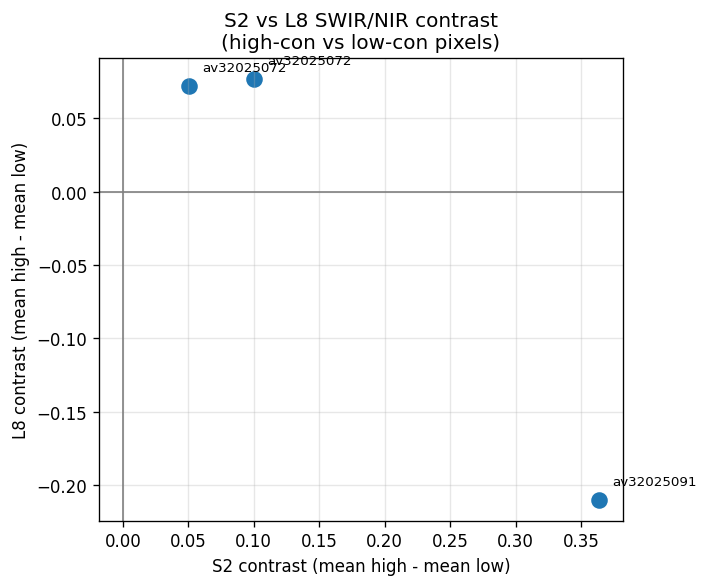


Per-plume contrasts:
av320250724t160634-A  S2_contrast=0.0503,  L8_contrast=0.0720
av320250724t160634-C  S2_contrast=0.1001,  L8_contrast=0.0768
av320250917t184127-A  S2_contrast=0.3637,  L8_contrast=-0.2101


In [56]:
import os
import numpy as np
import tifffile as tiff
import rasterio
from PIL import Image
import matplotlib.pyplot as plt

# -------------------------
# Utility functions
# -------------------------

def load_s2_stack(path):
    arr = tiff.imread(path).astype(np.float32)
    return arr  # (12,H,W)

def load_l8_stack(path):
    arr = tiff.imread(path).astype(np.float32)
    return arr  # (8,H,W)

def load_con(plume_id, target_shape, base_dir="../carbon_mapper_data_masks"):
    con_path = os.path.join(base_dir, plume_id, "con.tif")
    if not os.path.exists(con_path):
        print(f"[warn] missing con.tif for {plume_id}")
        return None
    with rasterio.open(con_path) as src:
        con = src.read(1).astype(np.float32)
    H, W = target_shape
    con = np.array(Image.fromarray(con).resize((W, H), Image.BILINEAR))
    return con

# Translated comment
S2_BANDS = [4, 5, 6, 7, 10, 11]   # B05,B06,B07,B8A,B11,B12
L8_BANDS = [1, 2, 3, 4, 5, 6, 7]              # B5,B6,B7

def compute_swir_composites(s2_stack, l8_stack):
    """
 filter bands composite,  z-normalize .
    """
    s2_sub = s2_stack[S2_BANDS]      # (6,H,W)
    l8_sub = l8_stack[L8_BANDS]      # (3,H,W)

    s2_comp = s2_sub.mean(axis=0)    # (H,W)
    l8_comp = l8_sub.mean(axis=0)    # (H,W)

    s2_comp = (s2_comp - s2_comp.mean()) / (s2_comp.std() + 1e-6)
    l8_comp = (l8_comp - l8_comp.mean()) / (l8_comp.std() + 1e-6)

    return s2_comp, l8_comp

# -------------------------
# Plume list
# -------------------------

SAMPLES = [
    dict(plume_id="av320250724t160634-A",
         s2_path="../carbonmapper_data_s2_l2a/av320250724t160634-A/s2_20250724T160829Z.tif",
         l8_path="../carbonmapper_data_l89_l2sp/av320250724t160634-A/l8_LC09_L2SP_018033_20250724_20250727_02_T1.tif"),

    dict(plume_id="av320250724t160634-C",
         s2_path="../carbonmapper_data_s2_l2a/av320250724t160634-C/s2_20250724T160829Z.tif",
         l8_path="../carbonmapper_data_l89_l2sp/av320250724t160634-C/l8_LC09_L2SP_018032_20250724_20250727_02_T1.tif"),

    dict(plume_id="av320250917t184127-A",
         s2_path="../carbonmapper_data_s2_l2a/av320250917t184127-A/s2_20250917T183919Z.tif",
         l8_path="../carbonmapper_data_l89_l2sp/av320250917t184127-A/l8_LC08_L2SP_043034_20250917_20250929_02_T1.tif"),

    dict(plume_id="ang20220824t183643-A",
         s2_path="../carbonmapper_data_s2_l2a/ang20220824t183643-A/s2_20220824T183919Z.tif",
         l8_path="../carbonmapper_data_l89_l2sp/ang20220824t183643-A/l8_LC08_L2SP_043023_20220824_20220924_02_T1.tif"),

    dict(plume_id="ang20220325t175529-A",
         s2_path="../carbonmapper_data_s2_l2a/ang20220325t175529-A/s2_20220325T175909Z.tif",
         l8_path="../carbonmapper_data_l89_l2sp/ang20220325t175529-A/l8_LC08_L2SP_035035_20220325_20220330_02_T1.tif"),
]

s2_contrasts = []
l8_contrasts = []
plume_ids = []

for sample in SAMPLES:
    pid = sample["plume_id"]
    print("Processing", pid)

    s2_stack = load_s2_stack(sample["s2_path"])
    l8_stack = load_l8_stack(sample["l8_path"])
    H, W = s2_stack.shape[1:]
    con_map = load_con(pid, (H, W))
    if con_map is None:
        continue

    # Translated comment
    s2_comp, l8_comp = compute_swir_composites(s2_stack, l8_stack)

    # Translated comment
    con_vals = con_map.flatten()
    valid = np.isfinite(con_vals) & (con_vals > np.percentile(con_vals, 10))
    con_valid = con_vals[valid]
    if con_valid.size < 100:
        print("  [warn] too few valid con pixels")
        continue

    q30 = np.percentile(con_valid, 0)
    q70 = np.percentile(con_valid, 80)

    high_mask = con_map >= q70
    low_mask  = con_map <= q30

    # Translated comment
    s2_high_mean = s2_comp[high_mask].mean()
    s2_low_mean  = s2_comp[low_mask].mean()
    l8_high_mean = l8_comp[high_mask].mean()
    l8_low_mean  = l8_comp[low_mask].mean()

    s2_contrast = s2_high_mean - s2_low_mean
    l8_contrast = l8_high_mean - l8_low_mean

    s2_contrasts.append(s2_contrast)
    l8_contrasts.append(l8_contrast)
    plume_ids.append(pid)

    print(f"  S2_contrast={s2_contrast:.4f},  L8_contrast={l8_contrast:.4f}")

# -------------------------
# Scatter plot: S2_contrast vs L8_contrast
# -------------------------

plt.figure(figsize=(6,5))
plt.scatter(s2_contrasts, l8_contrasts, s=80)

for x, y, pid in zip(s2_contrasts, l8_contrasts, plume_ids):
    plt.text(x + 0.01, y + 0.01, pid[:10], fontsize=8)

plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)

plt.xlabel("S2 contrast (mean high - mean low)")
plt.ylabel("L8 contrast (mean high - mean low)")
plt.title("S2 vs L8 SWIR/NIR contrast\n(high-con vs low-con pixels)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Translated comment
print("\nPer-plume contrasts:")
for pid, c2, c8 in zip(plume_ids, s2_contrasts, l8_contrasts):
    print(f"{pid:20s}  S2_contrast={c2:.4f},  L8_contrast={c8:.4f}")



Total pairs loaded from CSV: 1103
Processing GAO20230824t172827p0000-A
[warn] missing con.tif for GAO20230824t172827p0000-A
Processing GAO20230824t172827p0000-B
[warn] missing con.tif for GAO20230824t172827p0000-B
Processing GAO20230824t172827p0000-C
[warn] missing con.tif for GAO20230824t172827p0000-C
Processing GAO20230824t172827p0000-D
[warn] missing con.tif for GAO20230824t172827p0000-D
Processing GAO20230824t172827p0000-E
[warn] missing con.tif for GAO20230824t172827p0000-E
Processing GAO20230824t172827p0000-F
[warn] missing con.tif for GAO20230824t172827p0000-F
Processing GAO20230824t172827p0000-G
[warn] missing con.tif for GAO20230824t172827p0000-G
Processing GAO20230824t172827p0000-H
[warn] missing con.tif for GAO20230824t172827p0000-H
Processing GAO20230824t173950p0000-A
[warn] missing con.tif for GAO20230824t173950p0000-A
Processing GAO20230824t173950p0000-B
[warn] missing con.tif for GAO20230824t173950p0000-B
Processing GAO20230824t173950p0000-C
[warn] missing con.tif for GA

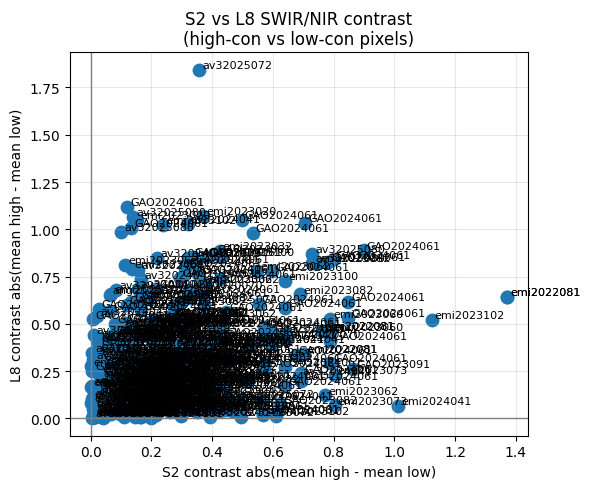


Per-plume contrasts:
GAO20230825t163030p0000-A  S2_contrast=0.6241,  L8_contrast=0.0745
GAO20230912t194153p0000-A  S2_contrast=0.8642,  L8_contrast=0.2623
GAO20240416t190730p0000-D  S2_contrast=0.3346,  L8_contrast=0.1988
GAO20240416t193330p0000-K  S2_contrast=0.1439,  L8_contrast=0.0738
GAO20240416t195905p0000-A  S2_contrast=0.0495,  L8_contrast=0.0669
GAO20240416t202440p0000-G  S2_contrast=0.0068,  L8_contrast=0.5236
GAO20240416t205015p0000-E  S2_contrast=0.3622,  L8_contrast=0.1684
GAO20240417t173913p0000-I  S2_contrast=0.0106,  L8_contrast=0.0840
GAO20240417t173913p0000-J  S2_contrast=0.0662,  L8_contrast=0.0223
GAO20240514t161405p0000-CC  S2_contrast=0.3611,  L8_contrast=0.3422
GAO20240514t161405p0000-CG  S2_contrast=0.1098,  L8_contrast=0.1943
GAO20240514t161405p0000-CH  S2_contrast=0.3378,  L8_contrast=0.2041
GAO20240514t161405p0000-CI  S2_contrast=0.0969,  L8_contrast=0.0220
GAO20240514t161405p0000-CJ  S2_contrast=0.0315,  L8_contrast=0.0346
GAO20240514t165911p0000-S  S2_contr

In [1]:
import os
import csv
import numpy as np
import tifffile as tiff
import rasterio
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# -------------------------
# Translated comment
# -------------------------

matched_csv = Path("matched_s2_l8_plumes.csv")

SAMPLES = []
seen = set()

with matched_csv.open() as f:
    reader = csv.DictReader(f)
    for row in reader:
        pid = row["plume_id"]
        s2_path = row["s2_path"]
        l8_path = row["l8_path"]
        key = (pid, s2_path, l8_path)
        if key in seen:
            continue
        seen.add(key)
        SAMPLES.append(dict(
            plume_id=pid,
            s2_path=s2_path,
            l8_path=l8_path,
        ))

print(f"Total pairs loaded from CSV: {len(SAMPLES)}")

# -------------------------
# Utility functions
# -------------------------

def load_s2_stack(path):
    arr = tiff.imread(path).astype(np.float32)
    return arr  # (12,H,W)

def load_l8_stack(path):
    arr = tiff.imread(path).astype(np.float32)
    return arr  # (8,H,W)

def load_con(plume_id, target_shape, base_dir="../carbon_mapper_data_masks"):
    con_path = os.path.join(base_dir, plume_id, "con.tif")
    if not os.path.exists(con_path):
        print(f"[warn] missing con.tif for {plume_id}")
        return None
    with rasterio.open(con_path) as src:
        con = src.read(1).astype(np.float32)
    H, W = target_shape
    con = np.array(Image.fromarray(con).resize((W, H), Image.BILINEAR))
    return con

# Translated comment
S2_BANDS = [4, 5, 6, 7, 10, 11]   # B05,B06,B07,B8A,B11,B12
L8_BANDS = [3,4, 5, 6,7]              # B5,B6,B7

def compute_swir_composites(s2_stack, l8_stack):
    """
 filter bands composite,  z-normalize .
    """
    s2_sub = s2_stack[S2_BANDS]      # (6,H,W)
    l8_sub = l8_stack[L8_BANDS]      # (3,H,W)

    s2_comp = s2_sub.mean(axis=0)    # (H,W)
    l8_comp = l8_sub.mean(axis=0)    # (H,W)

    s2_comp = (s2_comp - s2_comp.mean()) / (s2_comp.std() + 1e-6)
    l8_comp = (l8_comp - l8_comp.mean()) / (l8_comp.std() + 1e-6)

    return s2_comp, l8_comp

# -------------------------
# Translated comment
# -------------------------

s2_contrasts = []
l8_contrasts = []
plume_ids = []

total_samples = 0
skipped_missing_con = 0
skipped_few_con = 0
skipped_other = 0

for sample in SAMPLES:
    pid = sample["plume_id"]
    s2_path = sample["s2_path"]
    l8_path = sample["l8_path"]
    total_samples += 1

    print("Processing", pid)

    if (not os.path.exists(s2_path)) or (not os.path.exists(l8_path)):
        print(f"  [warn] missing S2 or L8 file: {s2_path}, {l8_path}")
        skipped_other += 1
        continue

    try:
        s2_stack = load_s2_stack(s2_path)
        l8_stack = load_l8_stack(l8_path)
    except Exception as e:
        print(f"  [warn] error loading stacks: {e}")
        skipped_other += 1
        continue

    H, W = s2_stack.shape[1:]
    con_map = load_con(pid, (H, W))
    if con_map is None:
        skipped_missing_con += 1
        continue

    # Translated comment
    s2_comp, l8_comp = compute_swir_composites(s2_stack, l8_stack)

    # Translated comment
    con_vals = con_map.flatten()
    valid = np.isfinite(con_vals) & (con_vals > np.percentile(con_vals, 10))
    con_valid = con_vals[valid]
    if con_valid.size < 100:
        print("  [warn] too few valid con pixels")
        skipped_few_con += 1
        continue

    # Translated comment
    q30 = np.percentile(con_valid, 0)
    q70 = np.percentile(con_valid, 50)

    high_mask = con_map >= q70
    low_mask  = con_map <= q30

    # Translated comment
    if high_mask.sum() < 10 or low_mask.sum() < 10:
        print("  [warn] high/low mask too small")
        skipped_other += 1
        continue

    # Translated comment
    s2_high_mean = s2_comp[high_mask].mean()
    s2_low_mean  = s2_comp[low_mask].mean()
    l8_high_mean = l8_comp[high_mask].mean()
    l8_low_mean  = l8_comp[low_mask].mean()

    s2_contrast = np.abs(s2_high_mean - s2_low_mean)
    l8_contrast = np.abs(l8_high_mean - l8_low_mean)

    s2_contrasts.append(s2_contrast)
    l8_contrasts.append(l8_contrast)
    plume_ids.append(pid)

    print(f"  S2_contrast={s2_contrast:.4f},  L8_contrast={l8_contrast:.4f}")

# -------------------------
# Translated comment
# -------------------------

print("\n========== Stats ==========")
print(f"Total samples in CSV      : {total_samples}")
print(f"Plotted points            : {len(plume_ids)}")
print(f"Skipped (missing con.tif) : {skipped_missing_con}")
print(f"Skipped (few con pixels)  : {skipped_few_con}")
print(f"Skipped (other issues)    : {skipped_other}")

# -------------------------
# Scatter plot: S2_contrast vs L8_contrast
# -------------------------

if plume_ids:
    plt.figure(figsize=(6,5))
    plt.scatter(s2_contrasts, l8_contrasts, s=80)

    for x, y, pid in zip(s2_contrasts, l8_contrasts, plume_ids):
        plt.text(x + 0.01, y + 0.01, pid[:10], fontsize=8)

    plt.axhline(0, color='gray', lw=1)
    plt.axvline(0, color='gray', lw=1)

    plt.xlabel("S2 contrast abs(mean high - mean low)")
    plt.ylabel("L8 contrast abs(mean high - mean low)")
    plt.title("S2 vs L8 SWIR/NIR contrast\n(high-con vs low-con pixels)")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nPer-plume contrasts:")
    for pid, c2, c8 in zip(plume_ids, s2_contrasts, l8_contrasts):
        print(f"{pid:20s}  S2_contrast={c2:.4f},  L8_contrast={c8:.4f}")
else:
    print("No valid points to plot.")


Total pairs loaded from CSV: 1103
Processing GAO20230824t172827p0000-A
  S2_contrast=0.0587,  L8_contrast=0.0317
Processing GAO20230824t172827p0000-B
  S2_contrast=0.0770,  L8_contrast=0.0291
Processing GAO20230824t172827p0000-C
  S2_contrast=0.0925,  L8_contrast=0.5058
Processing GAO20230824t172827p0000-D
  S2_contrast=0.0261,  L8_contrast=0.3842
Processing GAO20230824t172827p0000-E
  S2_contrast=0.0771,  L8_contrast=0.2715
Processing GAO20230824t172827p0000-F
  S2_contrast=0.4098,  L8_contrast=0.2650
Processing GAO20230824t172827p0000-G
  S2_contrast=0.0432,  L8_contrast=0.1354
Processing GAO20230824t172827p0000-H
  S2_contrast=0.3797,  L8_contrast=0.5944
Processing GAO20230824t173950p0000-A
  S2_contrast=0.1406,  L8_contrast=0.1312
Processing GAO20230824t173950p0000-B
  S2_contrast=0.1232,  L8_contrast=0.1039
Processing GAO20230824t173950p0000-C
  S2_contrast=0.0263,  L8_contrast=0.0550
Processing GAO20230824t173950p0000-D
  S2_contrast=0.0515,  L8_contrast=0.0517
Processing GAO2023

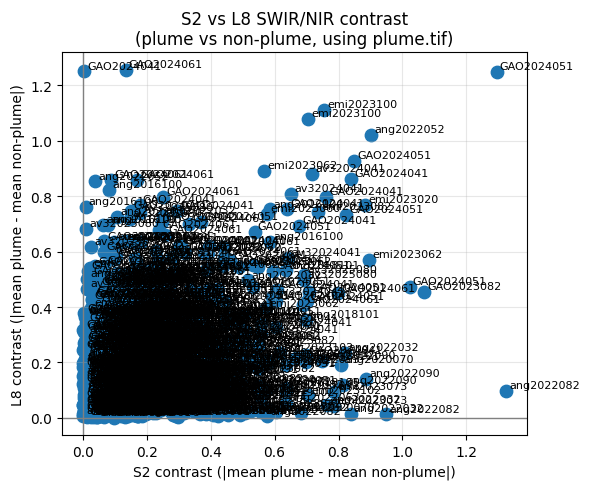


Per-plume contrasts:
GAO20230824t172827p0000-A  S2_contrast=0.0587,  L8_contrast=0.0317
GAO20230824t172827p0000-B  S2_contrast=0.0770,  L8_contrast=0.0291
GAO20230824t172827p0000-C  S2_contrast=0.0925,  L8_contrast=0.5058
GAO20230824t172827p0000-D  S2_contrast=0.0261,  L8_contrast=0.3842
GAO20230824t172827p0000-E  S2_contrast=0.0771,  L8_contrast=0.2715
GAO20230824t172827p0000-F  S2_contrast=0.4098,  L8_contrast=0.2650
GAO20230824t172827p0000-G  S2_contrast=0.0432,  L8_contrast=0.1354
GAO20230824t172827p0000-H  S2_contrast=0.3797,  L8_contrast=0.5944
GAO20230824t173950p0000-A  S2_contrast=0.1406,  L8_contrast=0.1312
GAO20230824t173950p0000-B  S2_contrast=0.1232,  L8_contrast=0.1039
GAO20230824t173950p0000-C  S2_contrast=0.0263,  L8_contrast=0.0550
GAO20230824t173950p0000-D  S2_contrast=0.0515,  L8_contrast=0.0517
GAO20230824t173950p0000-E  S2_contrast=0.0897,  L8_contrast=0.1614
GAO20230824t173950p0000-F  S2_contrast=0.3849,  L8_contrast=0.0158
GAO20230824t173950p0000-G  S2_contrast=0

In [9]:
import os
import csv
import numpy as np
import tifffile as tiff
import rasterio
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# -------------------------
# Translated comment
# -------------------------

matched_csv = Path("matched_s2_l8_plumes.csv")

SAMPLES = []
seen = set()

with matched_csv.open() as f:
    reader = csv.DictReader(f)
    for row in reader:
        pid = row["plume_id"]
        s2_path = row["s2_path"]
        l8_path = row["l8_path"]
        key = (pid, s2_path, l8_path)
        if key in seen:
            continue
        seen.add(key)
        SAMPLES.append(dict(
            plume_id=pid,
            s2_path=s2_path,
            l8_path=l8_path,
        ))

print(f"Total pairs loaded from CSV: {len(SAMPLES)}")

# -------------------------
# Utility functions
# -------------------------

def load_s2_stack(path):
    arr = tiff.imread(path).astype(np.float32)
    return arr  # (12,H,W)

def load_l8_stack(path):
    arr = tiff.imread(path).astype(np.float32)
    return arr  # (8,H,W)

def load_plume_mask(plume_id, target_shape, base_dir="../carbon_mapper_data_masks"):
    """
 load plume.tif, resize , float32 (0/1).
    """
    plume_path = os.path.join(base_dir, plume_id, "plume.tif")
    if not os.path.exists(plume_path):
        print(f"[warn] missing plume.tif for {plume_id}")
        return None
    with rasterio.open(plume_path) as src:
        plume = src.read(1).astype(np.float32)
    H, W = target_shape
    # Translated comment
    plume_resized = np.array(
        Image.fromarray(plume).resize((W, H), Image.NEAREST),
        dtype=np.float32
    )
    return plume_resized

# Translated comment
S2_BANDS = [4, 5, 6, 7, 10, 11]   # B05,B06,B07,B8A,B11,B12
L8_BANDS = [3, 4, 5, 6, 7]  # Translated comment

def compute_swir_composites(s2_stack, l8_stack):
    """
 filter bands composite,  z-normalize .
    """
    s2_sub = s2_stack[S2_BANDS]      # (C_s2,H,W)
    l8_sub = l8_stack[L8_BANDS]      # (C_l8,H,W)

    s2_comp = s2_sub.mean(axis=0)    # (H,W)
    l8_comp = l8_sub.mean(axis=0)    # (H,W)

    s2_comp = (s2_comp - s2_comp.mean()) / (s2_comp.std() + 1e-6)
    l8_comp = (l8_comp - l8_comp.mean()) / (l8_comp.std() + 1e-6)

    return s2_comp, l8_comp

# -------------------------
# Translated comment
# -------------------------

s2_contrasts = []
l8_contrasts = []
plume_ids = []

total_samples = 0
skipped_missing_plume = 0
skipped_small_plume = 0
skipped_other = 0

for sample in SAMPLES:
    pid = sample["plume_id"]
    s2_path = sample["s2_path"]
    l8_path = sample["l8_path"]
    total_samples += 1

    print("Processing", pid)

    if (not os.path.exists(s2_path)) or (not os.path.exists(l8_path)):
        print(f"  [warn] missing S2 or L8 file: {s2_path}, {l8_path}")
        skipped_other += 1
        continue

    try:
        s2_stack = load_s2_stack(s2_path)
        l8_stack = load_l8_stack(l8_path)
    except Exception as e:
        print(f"  [warn] error loading stacks: {e}")
        skipped_other += 1
        continue

    H, W = s2_stack.shape[1:]
    plume_mask = load_plume_mask(pid, (H, W))
    if plume_mask is None:
        skipped_missing_plume += 1
        continue

    # Translated comment
    s2_comp, l8_comp = compute_swir_composites(s2_stack, l8_stack)

    # Translated comment
    # Translated comment
    high_mask = plume_mask > 0.5
    low_mask  = plume_mask <= 0.5

    n_high = high_mask.sum()
    n_low  = low_mask.sum()

    if n_high < 10 or n_low < 10:
        print(f"  [warn] plume region too small or empty: high={n_high}, low={n_low}")
        skipped_small_plume += 1
        continue

    # Translated comment
    s2_high_mean = s2_comp[high_mask].mean()
    s2_low_mean  = s2_comp[low_mask].mean()
    l8_high_mean = l8_comp[high_mask].mean()
    l8_low_mean  = l8_comp[low_mask].mean()

    # Translated comment
    s2_contrast = np.abs(s2_high_mean - s2_low_mean)
    l8_contrast = np.abs(l8_high_mean - l8_low_mean)

    s2_contrasts.append(s2_contrast)
    l8_contrasts.append(l8_contrast)
    plume_ids.append(pid)

    print(f"  S2_contrast={s2_contrast:.4f},  L8_contrast={l8_contrast:.4f}")

# -------------------------
# Translated comment
# -------------------------

print("\n========== Stats ==========")
print(f"Total samples in CSV         : {total_samples}")
print(f"Plotted points               : {len(plume_ids)}")
print(f"Skipped (missing plume.tif)  : {skipped_missing_plume}")
print(f"Skipped (plume too small)    : {skipped_small_plume}")
print(f"Skipped (other issues)       : {skipped_other}")

# -------------------------
# Scatter plot: S2_contrast vs L8_contrast
# -------------------------

if plume_ids:
    plt.figure(figsize=(6,5))
    plt.scatter(s2_contrasts, l8_contrasts, s=80)

    for x, y, pid in zip(s2_contrasts, l8_contrasts, plume_ids):
        plt.text(x + 0.01, y + 0.01, pid[:10], fontsize=8)

    plt.axhline(0, color='gray', lw=1)
    plt.axvline(0, color='gray', lw=1)

    plt.xlabel("S2 contrast (|mean plume - mean non-plume|)")
    plt.ylabel("L8 contrast (|mean plume - mean non-plume|)")
    plt.title("S2 vs L8 SWIR/NIR contrast\n(plume vs non-plume, using plume.tif)")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nPer-plume contrasts:")
    for pid, c2, c8 in zip(plume_ids, s2_contrasts, l8_contrasts):
        print(f"{pid:20s}  S2_contrast={c2:.4f},  L8_contrast={c8:.4f}")
else:
    print("No valid points to plot.")


In [1]:
import numpy as np
import os
import csv
import numpy as np
import tifffile as tiff
import rasterio
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# -------------------------
# Translated comment
# -------------------------

# matched_csv = Path("matched_s2_l8_plumes.csv")
matched_csv = Path("for_ratio_cm_s2_l8_matches_within_24h.csv")

SAMPLES = []
seen = set()

with matched_csv.open() as f:
    reader = csv.DictReader(f)
    for row in reader:
        pid = row["plume_id"]
        s2_path = row["s2_path"]
        l8_path = row["l8_path"]
        key = (pid, s2_path, l8_path)
        if key in seen:
            continue
        seen.add(key)
        SAMPLES.append(dict(
            plume_id=pid,
            s2_path=s2_path,
            l8_path=l8_path,
        ))

print(f"Total pairs loaded from CSV: {len(SAMPLES)}")

# -------------------------
# Utility functions
# -------------------------

def load_s2_stack(path):
    arr = tiff.imread(path).astype(np.float32)
    return arr  # (12,H,W)

def load_l8_stack(path):
    arr = tiff.imread(path).astype(np.float32)
    return arr  # (8,H,W)

def load_plume_mask(plume_id, target_shape, base_dir="../carbon_mapper_data_masks"):
    """
 load plume.tif, resize , float32 (0/1).
    """
    plume_path = os.path.join(base_dir, plume_id, "plume.tif")
    if not os.path.exists(plume_path):
        print(f"[warn] missing plume.tif for {plume_id}")
        return None
    with rasterio.open(plume_path) as src:
        plume = src.read(1).astype(np.float32)
    H, W = target_shape
    # Translated comment
    plume_resized = np.array(
        Image.fromarray(plume).resize((W, H), Image.NEAREST),
        dtype=np.float32
    )
    return plume_resized

# Translated comment
S2_BANDS = [4, 5, 6, 7, 10, 11]   # B05,B06,B07,B8A,B11,B12
L8_BANDS = [3, 4, 5, 6, 7]  # Translated comment

def compute_swir_composites(s2_stack, l8_stack):
    """
 filter bands composite,  z-normalize .
    """
    s2_sub = s2_stack[S2_BANDS]      # (C_s2,H,W)
    l8_sub = l8_stack[L8_BANDS]      # (C_l8,H,W)

    s2_comp = s2_sub.mean(axis=0)    # (H,W)
    l8_comp = l8_sub.mean(axis=0)    # (H,W)

    s2_comp = (s2_comp - s2_comp.mean()) / (s2_comp.std() + 1e-6)
    l8_comp = (l8_comp - l8_comp.mean()) / (l8_comp.std() + 1e-6)

    return s2_comp, l8_comp

# -------------------------
# Translated comment
# -------------------------

s2_contrasts = []
l8_contrasts = []
plume_ids = []

total_samples = 0
skipped_missing_plume = 0
skipped_small_plume = 0
skipped_other = 0

for sample in SAMPLES:
    pid = sample["plume_id"]
    s2_path = sample["s2_path"]
    l8_path = sample["l8_path"]
    total_samples += 1

    print("Processing", pid)

    if (not os.path.exists(s2_path)) or (not os.path.exists(l8_path)):
        print(f"  [warn] missing S2 or L8 file: {s2_path}, {l8_path}")
        skipped_other += 1
        continue

    try:
        s2_stack = load_s2_stack(s2_path)
        l8_stack = load_l8_stack(l8_path)
    except Exception as e:
        print(f"  [warn] error loading stacks: {e}")
        skipped_other += 1
        continue

    H, W = s2_stack.shape[1:]
    plume_mask = load_plume_mask(pid, (H, W))
    if plume_mask is None:
        skipped_missing_plume += 1
        continue

    # Translated comment
    s2_comp, l8_comp = compute_swir_composites(s2_stack, l8_stack)

    # Translated comment
    # Translated comment
    high_mask = plume_mask > 0.5
    low_mask  = plume_mask <= 0.5

    n_high = high_mask.sum()
    n_low  = low_mask.sum()

    if n_high < 10 or n_low < 10:
        print(f"  [warn] plume region too small or empty: high={n_high}, low={n_low}")
        skipped_small_plume += 1
        continue

    # Translated comment
    s2_high_mean = s2_comp[high_mask].mean()
    s2_low_mean  = s2_comp[low_mask].mean()
    l8_high_mean = l8_comp[high_mask].mean()
    l8_low_mean  = l8_comp[low_mask].mean()

    # Translated comment
    s2_contrast = np.abs(s2_high_mean - s2_low_mean)
    l8_contrast = np.abs(l8_high_mean - l8_low_mean)

    s2_contrasts.append(s2_contrast)
    l8_contrasts.append(l8_contrast)
    plume_ids.append(pid)

    print(f"  S2_contrast={s2_contrast:.4f},  L8_contrast={l8_contrast:.4f}")

# -------------------------
# Translated comment
# -------------------------

print("\n========== Stats ==========")
print(f"Total samples in CSV         : {total_samples}")
print(f"Plotted points               : {len(plume_ids)}")
print(f"Skipped (missing plume.tif)  : {skipped_missing_plume}")
print(f"Skipped (plume too small)    : {skipped_small_plume}")
print(f"Skipped (other issues)       : {skipped_other}")

s2_arr = np.array(s2_contrasts)
l8_arr = np.array(l8_contrasts)

# Translated comment
strength = np.maximum(s2_arr, l8_arr)

# Translated comment
thr = np.percentile(strength, 50)  # Translated comment
mask_strong = (np.abs(strength) >= thr)

print(f"Total plotted plumes      : {len(s2_arr)}")
print(f"Strong plumes (>=70% perc): {mask_strong.sum()}")
# Translated comment
delta = l8_arr - s2_arr  # Translated comment
mask_l8_dom = (mask_strong) & (delta > 0)
mask_s2_dom = (mask_strong) & (delta < 0)
mask_similar = (mask_strong) & (np.abs(delta) <= 0.05)  # Translated comment
print(f"L8-dominant strong plumes : {mask_l8_dom.sum()}")
print(f"S2-dominant strong plumes : {mask_s2_dom.sum()}")
print(f"Similar (|Δ|<=0.05)       : {mask_similar.sum()}")

# -------------------------
# Translated comment
# -------------------------
plt.figure(figsize=(6, 5))

# Translated comment
plt.scatter(s2_arr[~mask_strong], l8_arr[~mask_strong],
            s=10, alpha=0.2, color="lightgray", label="weak plumes")

# strong + S2-dominant
plt.scatter(s2_arr[mask_s2_dom], l8_arr[mask_s2_dom],
            s=60, color="tab:orange", label="S2-dominant")

# strong + L8-dominant
plt.scatter(s2_arr[mask_l8_dom], l8_arr[mask_l8_dom],
            s=60, color="tab:blue", label="L8-dominant")

# Translated comment
for idx in np.where(mask_s2_dom)[0][:10]:
    plt.text(s2_arr[idx]+0.01, l8_arr[idx]+0.01, plume_ids[idx][:10],
             fontsize=7, color="tab:orange")
for idx in np.where(mask_l8_dom)[0][:10]:
    plt.text(s2_arr[idx]+0.01, l8_arr[idx]+0.01, plume_ids[idx][:10],
             fontsize=7, color="tab:blue")

plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.plot([0, max(s2_arr.max(), l8_arr.max())],
         [0, max(s2_arr.max(), l8_arr.max())],
         'k--', alpha=0.5)  # Translated comment

plt.xlabel("S2 contrast (|mean plume - mean non-plume|)")
plt.ylabel("L8 contrast (|mean plume - mean non-plume|)")
plt.title("S2 vs L8 SWIR/NIR contrast\nstrong plumes only (plume vs non-plume)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Total pairs loaded from CSV: 1373
Processing GAO20230824t172827p0000-A
  [warn] missing S2 or L8 file: /data2/yuyao/methane_emission/data/raw_data_dir/S2B_MSIL2A_20230825T171859_N0510_R012_T14SKA_20241017T081533.SAFE, /data2/yuyao/methane_emission/carbonmapper_data_l89_l2sp/GAO20230824t172827p0000-A/l8_LC09_L2SP_030038_20230824_20230826_02_T1.tif
Processing GAO20230824t172827p0000-A
  [warn] missing S2 or L8 file: /data2/yuyao/methane_emission/data/raw_data_dir/S2B_MSIL2A_20230825T171859_N0510_R012_T13SGR_20241017T081533.SAFE, /data2/yuyao/methane_emission/carbonmapper_data_l89_l2sp/GAO20230824t172827p0000-A/l8_LC09_L2SP_030038_20230824_20230826_02_T1.tif
Processing GAO20230824t172827p0000-B
  [warn] missing S2 or L8 file: /data2/yuyao/methane_emission/data/raw_data_dir/S2B_MSIL2A_20230825T171859_N0510_R012_T13SGR_20241017T081533.SAFE, /data2/yuyao/methane_emission/carbonmapper_data_l89_l2sp/GAO20230824t172827p0000-B/l8_LC09_L2SP_030038_20230824_20230826_02_T1.tif
Processing GAO2023082

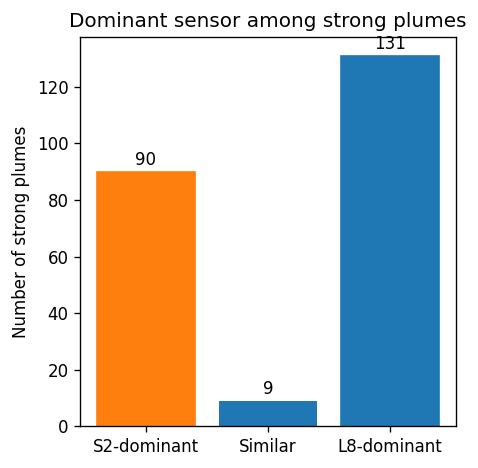

In [71]:
cats = ["S2-dominant", "Similar", "L8-dominant"]
vals = [mask_s2_dom.sum(), mask_similar.sum(), mask_l8_dom.sum()]

plt.figure(figsize=(4,4))
bars = plt.bar(cats, vals)
bars[0].set_color("tab:orange")
bars[2].set_color("tab:blue")

for i, v in enumerate(vals):
    plt.text(i, v + 1, str(v), ha="center", va="bottom")

plt.ylabel("Number of strong plumes")
plt.title("Dominant sensor among strong plumes")
plt.tight_layout()
plt.show()